In [18]:
# =====================================================================
# CELL 0 — Upload data (run once per Colab session; files stay on disk until the runtime is deleted)
# Required: CES6054150001.csv, lowest_price_models_data.csv, CPIAUCSL.csv, PSAVERT.csv, LNU05026642.csv
# Optional: PCE.csv (FRED series PCE) — only for the budget-feedback test in Cell 16
# =====================================================================
import os
DATA_DIR = '/content/data'
os.makedirs(DATA_DIR, exist_ok=True)
NEED = ['CES6054150001.csv', 'lowest_price_models_data.csv', 'CPIAUCSL.csv', 'PSAVERT.csv', 'LNU05026642.csv']
missing = [f for f in NEED if not os.path.exists(os.path.join(DATA_DIR, f))]
if missing:
    from google.colab import files
    print('Upload:', missing, '(and optionally PCE.csv)')
    up = files.upload()
    for name, content in up.items():
        clean = name.replace(' (1)', '').replace(' (2)', '')
        with open(os.path.join(DATA_DIR, clean), 'wb') as fh:
            fh.write(content)
print('In', DATA_DIR, ':', sorted(os.listdir(DATA_DIR)))
print('Still missing:', [f for f in NEED if not os.path.exists(os.path.join(DATA_DIR, f))] or 'none')

In /content/data : ['CES6054150001.csv', 'CPIAUCSL.csv', 'LNU05026642.csv', 'PSAVERT.csv', 'lowest_price_models_data.csv']
Still missing: none


In [19]:
%%writefile /content/ai_labour_model.py
# =====================================================================
# ai_labour_model.py — shared model file (written once by Cell 1).
# Every later cell imports this file and reads data from disk, so no cell depends on
# variables left in memory by another cell.
# Model: AI adoption -> tech displacement -> savings buffer -> switch -> spending by category
#        -> long run (new tasks, service wages, budget feedback)
# References:
#   Acemoglu & Restrepo (2018) AER 108(6): task rule eqs (1),(5),(6); new tasks raise N (Sect. II-III,
#       Prop. 6, Corollary 2) [V]
#   Applegate & Janssen (2022) Comp. Econ. 59: saving a share of the wage (Sect. 2 p.5, Table 1),
#       agent-based design, plot styles (Fig 2, 3, 5, 8; Tables 2, 5) [V]
#   Pissarides (2000) job finding [U]; Kaldor (1956) worker vs owner spending [U]; Kahn (1931) multiplier [U]
#   Geary (1950), Stone (1954) linear expenditure system (Stone-Geary) [U]
# Research gap: no existing model links AI token cost, fixed firm budgets, a savings clock after
#   firing, spending cuts by category, and the long-run demand loop in one agent-based model.
# =====================================================================
import os, pickle, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings('ignore')
try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
except ImportError:
    lowess = None

BASE = os.environ.get('AILM_BASE', '/content')
DATA_DIR = os.path.join(BASE, 'data')
RES_DIR = os.path.join(BASE, 'results')
FILES = ['CES6054150001.csv', 'lowest_price_models_data.csv',
         'CPIAUCSL.csv', 'PSAVERT.csv', 'LNU05026642.csv']
OPTIONAL = ['PCE.csv']            # FRED series PCE, needed only for the budget-feedback test (Cell 16)

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 10,
                     'axes.titleweight': 'bold', 'legend.frameon': False})
C_COLORS = {'data: q fixed': '#1f77b4', 'q offsets price': '#ff7f0e', 'q outruns price': '#d62728'}
RNG_SEED = 2026

# ====================== DATA (read from CSV at every import) ======================
_missing = [f for f in FILES if not os.path.exists(os.path.join(DATA_DIR, f))]
if _missing:
    raise FileNotFoundError(f'Missing in {DATA_DIR}: {_missing}. Run Cell 0 to upload them.')

def fred_csv(name):
    d = pd.read_csv(os.path.join(DATA_DIR, name))
    d.columns = ['date', 'value']
    d['date'] = pd.to_datetime(d['date'])
    d['value'] = pd.to_numeric(d['value'], errors='coerce')
    return d.dropna()

emp  = fred_csv('CES6054150001.csv')    # tech employment, thousand persons
cpi  = fred_csv('CPIAUCSL.csv')         # CPI, 1982-84 = 100
sav  = fred_csv('PSAVERT.csv')          # personal saving rate, %
marg = fred_csv('LNU05026642.csv')      # marginally attached, thousand persons
prices = pd.read_csv(os.path.join(DATA_DIR, 'lowest_price_models_data.csv'))
pce = fred_csv('PCE.csv') if os.path.exists(os.path.join(DATA_DIR, 'PCE.csv')) else None
PCE_M = None if pce is None else pce['value'].tail(12).mean() * 1e9 / 12   # $ per month

cpi_s = cpi.set_index('date')['value']
CPI_BASE = cpi_s.loc['2025-05-01']      # OEWS wage date
def to_real(x, date):
    return x * CPI_BASE / cpi_s.asof(pd.Timestamp(date))

coding = prices[(prices['Benchmark'] == 'HumanEval') &
                (prices['Threshold model'] == 'GPT-4-0314')].copy()
coding['date'] = pd.to_datetime(coding['Release Date'])
coding = coding.sort_values('date')
coding['real'] = [to_real(v, d) for v, d in zip(coding['USD per 1M Tokens'], coding['date'])]

# ====================== PARAMETERS: DATA / HAND / PLACEHOLDER ======================
L_IND = emp['value'].iloc[-1] * 1000
S_MEAN = sav['value'].mean() / 100
_t = (coding['date'] - coding['date'].iloc[0]).dt.days / 365.25
PT_DRIFT = np.polyfit(_t, np.log(coding['real']), 1)[0]

P = dict(
    start_year=2023, n_years=8,                      # base run 2023-2030
    L0=L_IND * 0.5,                                  # DATA x PLACEHOLDER junior/mid share 0.5
    W=148100 / 12,                                   # HAND OEWS May 2025: software developers, annual mean
    W_S=51560 / 12,                                  # HAND OEWS May 2025: office & admin support, annual mean
    L_service=17753430,                              # HAND OEWS May 2025: office & admin support employment
    eps_d=0.5,                                       # PLACEHOLDER labour-demand elasticity in service jobs
    n_tasks=20, g_ratio=1.15,                        # PLACEHOLDER task ladder (A&R Assumption 1)
    A_share=[0.10, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55],   # PLACEHOLDER share of tasks AI CAN do
    A_growth=0.03, A_cap=0.85,                       # PLACEHOLDER capability growth after 2030
    c0_rel=1.2,                                      # PLACEHOLDER AI cost / junior labour cost, 2023
    pT_drift=PT_DRIFT,                               # DATA (Epoch, fixed coding capability)
    q_scen={'data: q fixed': 0.0,
            'q offsets price': -PT_DRIFT,            # PLACEHOLDER scenario
            'q outruns price': -PT_DRIFT + 0.20},    # PLACEHOLDER scenario
    c_vol=0.15,                                      # PLACEHOLDER
    sigmas=[0.0, 0.5, 1.0],
    r_b=0.1, b=0.5, open_rt=0.04,                    # PLACEHOLDER
    s_mean=S_MEAN, s_sd=0.03,                        # DATA mean (floor); PLACEHOLDER spread
    ns_min=12, ns_max=60,                            # PLACEHOLDER months of saving before firing
    z_rel=0.0, m_min_rel=0.0,                        # PLACEHOLDER
    c_K=0.1, k_profit=1.0, labour_share=0.6,         # PLACEHOLDER
    N_agents=1000, R_runs=30,
)
TAGS = {'L0': 'DATA x PLACEHOLDER', 'W': 'HAND', 'W_S': 'HAND', 'L_service': 'HAND',
        'pT_drift': 'DATA', 's_mean': 'DATA (floor)', 's_sd': 'PLACEHOLDER', 'c0_rel': 'PLACEHOLDER',
        'z_rel': 'PLACEHOLDER', 'r_b': 'PLACEHOLDER', 'c_K': 'PLACEHOLDER', 'eps_d': 'PLACEHOLDER'}

# Stone-Geary spending categories (Step 6). ALL PLACEHOLDER until BLS Consumer Expenditure Survey is loaded.
# E_min = monthly minimum spending ($); a = share of spending above the minimum.
CATS = pd.DataFrame([
    ('housing',               1800, 0.30),
    ('basic food',             500, 0.08),
    ('fuel / transport',       400, 0.08),
    ('organic / premium food',   0, 0.07),
    ('supplements, protein',     0, 0.04),
    ('routine check-ups',        0, 0.05),
    ('other',                  300, 0.38),
], columns=['category', 'E_min', 'a']).set_index('category')

def c_mix():
    return (1 - P['s_mean']) * P['labour_share'] + P['c_K'] * (1 - P['labour_share'])

# ====================== STEP 1-2: firm (A&R eqs 5-6; fixed budget) ======================
def ladder(offset=0):
    g = P['g_ratio'] ** (np.arange(P['n_tasks']) + offset)
    return P['W'] / g                                     # e(k) = W / gamma(k)

e = ladder(0)

def headcount(ai, c, X, sigma, e_vec=None):
    ev = e if e_vec is None else e_vec
    p = np.where(ai, c, ev)
    s_W = (ev[~ai] ** (1 - sigma)).sum() / (p ** (1 - sigma)).sum()
    return X * s_W / P['W']

def allocate(c_plan, A_count, ai_prev, U_now, L_prev, X, sigma, e_vec=None):
    ev = e if e_vec is None else e_vec
    k = np.arange(P['n_tasks'])
    want = (k < A_count) & (c_plan < ev)                  # able AND cheaper
    ai = ai_prev | want                                   # lock-in
    for j in np.where(ai_prev & ~want)[0][::-1]:          # return a task only if rehiring is possible
        trial = ai.copy(); trial[j] = False
        if headcount(trial, c_plan, X, sigma, ev) - L_prev <= P['r_b'] * U_now:
            ai = trial
    return ai, headcount(ai, c_plan, X, sigma, ev)

def A_count_at(y):
    if y < len(P['A_share']):
        sh = P['A_share'][y]
    else:
        sh = min(P['A_cap'], P['A_share'][-1] + P['A_growth'] * (y - len(P['A_share']) + 1))
    return sh * P['n_tasks']                              # in original task units

# ====================== STEP 3-5: savings (Applegate & Janssen Sect. 2 p.5) ======================
def beta_ab(m, sd):
    v = sd ** 2; kk = m * (1 - m) / v - 1
    return m * kk, (1 - m) * kk

# ====================== STEP 6: Stone-Geary spending by category ======================
def les(budget):
    """Monthly spending by category for a household with monthly budget `budget`."""
    Emin = CATS['E_min'].values; a = CATS['a'].values
    if budget >= Emin.sum():
        return Emin + a * (budget - Emin.sum())
    return Emin * budget / Emin.sum()                     # below the floor: necessities cut, discretionary = 0

# ====================== MONTE CARLO ENGINE ======================
def run_once(rng, sigma, q_drift, n_years=None, nu=0.0, e_X=0.0, wage_resp=False, keep_paths=False):
    """One run. nu = new tasks per year as a share of n_tasks (A&R: N rises).
    e_X = elasticity of the tech budget to aggregate demand (needs PCE.csv). wage_resp = service wage responds."""
    ny = P['n_years'] if n_years is None else n_years
    T = 12 * ny; N = P['N_agents']; wgt = P['L0'] / N
    X = P['W'] * P['L0']                                  # before AI, whole budget is wages
    drift = P['pT_drift'] + q_drift
    eps = rng.standard_normal(ny); eps[0] = 0.0           # FIX: no random shock in the first year
    c_path = P['c0_rel'] * e[0] * np.exp(drift * np.arange(ny) + P['c_vol'] * np.cumsum(eps))
    a_, b_ = beta_ab(P['s_mean'], P['s_sd'])
    s_r = rng.beta(a_, b_, N)
    n_s = rng.integers(P['ns_min'], P['ns_max'] + 1, N)
    m = s_r * P['W'] * n_s                                # m(0) = s_r W n_s
    z = P['z_rel'] * P['W']; m_min = P['m_min_rel'] * P['W']
    state = np.zeros(N, int)                              # 0 tech job, 1 searching, 2 switched, 3 turnover exit
    ai = np.zeros(P['n_tasks'], bool); jobs = P['L0']; H_month = 0.0
    offset, new_acc, dAD_sum, W_S_t = 0, 0.0, 0.0, P['W_S']
    keys = ['jobs', 'emp_cohort', 'U', 'S', 'fired', 'switched', 'rehired', 'f', 'token',
            'dC', 'dC_switch', 'dC_service', 'dC_owner', 'dAD', 'W_S', 'c_A', 'X']
    out = {kk: np.zeros(T) for kk in keys}
    paths = np.zeros((T, 300)) if keep_paths else None
    for t in range(T):
        y = t // 12
        if t % 12 == 0:
            if y > 0 and e_X != 0 and PCE_M is not None:          # budget feedback (her notes p.4)
                X *= (1 + e_X * (dAD_sum / 12) / PCE_M)
            dAD_sum = 0.0
            if y > 0 and nu > 0:                                  # new tasks: add at top, drop bottom
                new_acc += nu * P['n_tasks']
                k_new = int(new_acc); new_acc -= k_new
                for _ in range(k_new):
                    ai = np.append(ai[1:], False); offset += 1
            ev = ladder(offset)
            c_plan = c_path[y - 1] if y > 0 else c_path[0]        # one-year cost lag
            A_rel = int(np.clip(round(A_count_at(y) - offset), 0, P['n_tasks']))
            ai, L_new = allocate(c_plan, A_rel, ai, (state == 1).sum() * wgt, jobs, X, sigma, ev)
            emp_idx = np.where(state == 0)[0]
            n_fire = min(len(emp_idx), int(round(max(0.0, jobs - L_new) / wgt)))
            if n_fire > 0:                                        # mass termination, random worker
                fire = rng.choice(emp_idx, n_fire, replace=False)
                state[fire] = 1; out['fired'][t] = n_fire * wgt
            H_month = max(0.0, L_new - jobs) / 12
            jobs = L_new
        # openings and job finding (Pissarides, simplest form)
        srch = np.where(state == 1)[0]
        V_turn = P['open_rt'] * jobs; V = V_turn + H_month
        f = min(1.0, P['b'] * V / (len(srch) * wgt)) if len(srch) else 0.0
        hired = srch[rng.random(len(srch)) < f]
        if len(hired):
            state[hired] = 0
            n_turn = int(round(len(hired) * V_turn / V))          # turnover openings: someone left
            pool = np.setdiff1d(np.where(state == 0)[0], hired)
            if n_turn > 0 and len(pool):
                state[rng.choice(pool, min(n_turn, len(pool)), replace=False)] = 3
            out['rehired'][t] = len(hired) * wgt
        # service wage falls as switchers enter service jobs
        S_tot = (state == 2).sum() * wgt
        W_S_t = P['W_S'] * (1 + S_tot / P['L_service']) ** (-1 / P['eps_d']) if wage_resp else P['W_S']
        # savings: employed and switched save s_r of income; searchers spend as before
        m[state == 0] += s_r[state == 0] * P['W']
        m[state == 2] += s_r[state == 2] * W_S_t
        srch = np.where(state == 1)[0]
        m[srch] += z - (1 - s_r[srch]) * P['W']
        gone = srch[m[srch] <= m_min]
        state[gone] = 2; m[gone] = np.maximum(m[gone], 0)
        out['switched'][t] = len(gone) * wgt
        # demand (her notes pp. 4-5, corrections 7-9)
        sw = state == 2
        token = X - P['W'] * jobs
        dC_switch = ((1 - s_r[sw]) * (W_S_t - P['W'])).sum() * wgt
        dC_service = (1 - P['s_mean']) * (W_S_t - P['W_S']) * P['L_service']
        dC_owner = P['c_K'] * P['k_profit'] * token
        dC = dC_switch + dC_service + dC_owner
        dAD = dC / (1 - c_mix()); dAD_sum += dAD
        for kk, v in [('jobs', jobs), ('emp_cohort', (state == 0).sum() * wgt), ('U', (state == 1).sum() * wgt),
                      ('S', sw.sum() * wgt), ('f', f), ('token', token), ('dC', dC),
                      ('dC_switch', dC_switch), ('dC_service', dC_service), ('dC_owner', dC_owner),
                      ('dAD', dAD), ('W_S', W_S_t), ('c_A', c_plan), ('X', X)]:
            out[kk][t] = v
        if keep_paths: paths[t] = np.where(state[:300] == 3, np.nan, m[:300])
    alive = state != 3
    income = np.select([state == 0, state == 1, state == 2], [P['W'], z, W_S_t], 0.0)
    end = dict(income=income[alive], wealth=m[alive], state=state[alive], s_r=s_r[alive])
    return out, end, (paths, state[:300]) if keep_paths else None

# ====================== RUNNERS WITH DISK CACHE ======================
def _hash(extra=''):
    return hashlib.md5((repr(sorted((k, str(v)) for k, v in P.items())) + CATS.to_json() + extra).encode()).hexdigest()

def _months(ny):
    return pd.date_range(f"{P['start_year']}-01-01", periods=12 * ny, freq='MS')

def get_results(force=False):
    """Base scenarios (sigma x token cost), 2023-2030. Loads from disk; reruns if missing or parameters changed."""
    path = os.path.join(RES_DIR, 'base.pkl'); h = _hash('base')
    if not force and os.path.exists(path):
        d = pickle.load(open(path, 'rb'))
        if d['hash'] == h:
            return d['RES'], d['END'], d['PATHS'], _months(P['n_years'])
        print('Parameters changed: rerunning the base Monte Carlo.')
    elif not force:
        print('No saved base results: running the Monte Carlo (1-2 minutes).')
    RES, END, PATHS = {}, {}, {}
    rng = np.random.default_rng(RNG_SEED)
    for s in P['sigmas']:
        for cname, qd in P['q_scen'].items():
            runs, ends = [], []
            for r in range(P['R_runs']):
                o, en, pth = run_once(rng, s, qd, keep_paths=(r == 0))
                runs.append(o); ends.append(en)
                if r == 0: PATHS[(s, cname)] = pth
            RES[(s, cname)] = {kk: np.array([o[kk] for o in runs]) for kk in runs[0]}
            END[(s, cname)] = ends
            print(f'  done: sigma={s}, {cname}')
    os.makedirs(RES_DIR, exist_ok=True)
    pickle.dump(dict(hash=h, RES=RES, END=END, PATHS=PATHS), open(path, 'wb'))
    return RES, END, PATHS, _months(P['n_years'])

def get_longrun(name, settings, n_years=18, R=20, force=False):
    """Long-run scenarios. settings: dict label -> dict(sigma, cname, nu, e_X, wage_resp)."""
    path = os.path.join(RES_DIR, f'long_{name}.pkl'); h = _hash(name + repr(settings) + str(n_years) + str(R))
    if not force and os.path.exists(path):
        d = pickle.load(open(path, 'rb'))
        if d['hash'] == h:
            return d['RES'], _months(n_years)
    print(f'Running long-run set "{name}" ({len(settings)} scenarios x {R} runs)...')
    RES = {}; rng = np.random.default_rng(RNG_SEED + 1)
    for lab, st in settings.items():
        runs = [run_once(rng, st['sigma'], P['q_scen'][st['cname']], n_years=n_years, nu=st['nu'],
                         e_X=st['e_X'], wage_resp=st['wage_resp'])[0] for _ in range(R)]
        RES[lab] = {kk: np.array([o[kk] for o in runs]) for kk in runs[0]}
        print(f'  done: {lab}')
    os.makedirs(RES_DIR, exist_ok=True)
    pickle.dump(dict(hash=h, RES=RES), open(path, 'wb'))
    return RES, _months(n_years)

# ====================== PLOT HELPERS ======================
def smooth(y):
    x = np.arange(len(y))
    if lowess is not None:
        return lowess(y, x, frac=0.25, return_sorted=False)
    return pd.Series(y).rolling(6, min_periods=1, center=True).mean().values

def band(ax, x, arr, col, label=None, scale=1.0):
    q5, q50, q95 = np.percentile(arr / scale, [5, 50, 95], axis=0)
    ax.plot(x, q50, color=col, lw=2, label=label); ax.fill_between(x, q5, q95, color=col, alpha=0.15)

def lorenz(x):
    x = np.sort(np.maximum(x, 0)); cx = np.cumsum(x)
    return np.linspace(0, 1, len(x) + 1), (np.insert(cx / cx[-1], 0, 0) if cx[-1] > 0 else np.zeros(len(x) + 1))

def gini(x):
    x = np.sort(np.maximum(x, 0)); n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum()) - (n + 1) / n) if x.sum() > 0 else np.nan

Writing /content/ai_labour_model.py


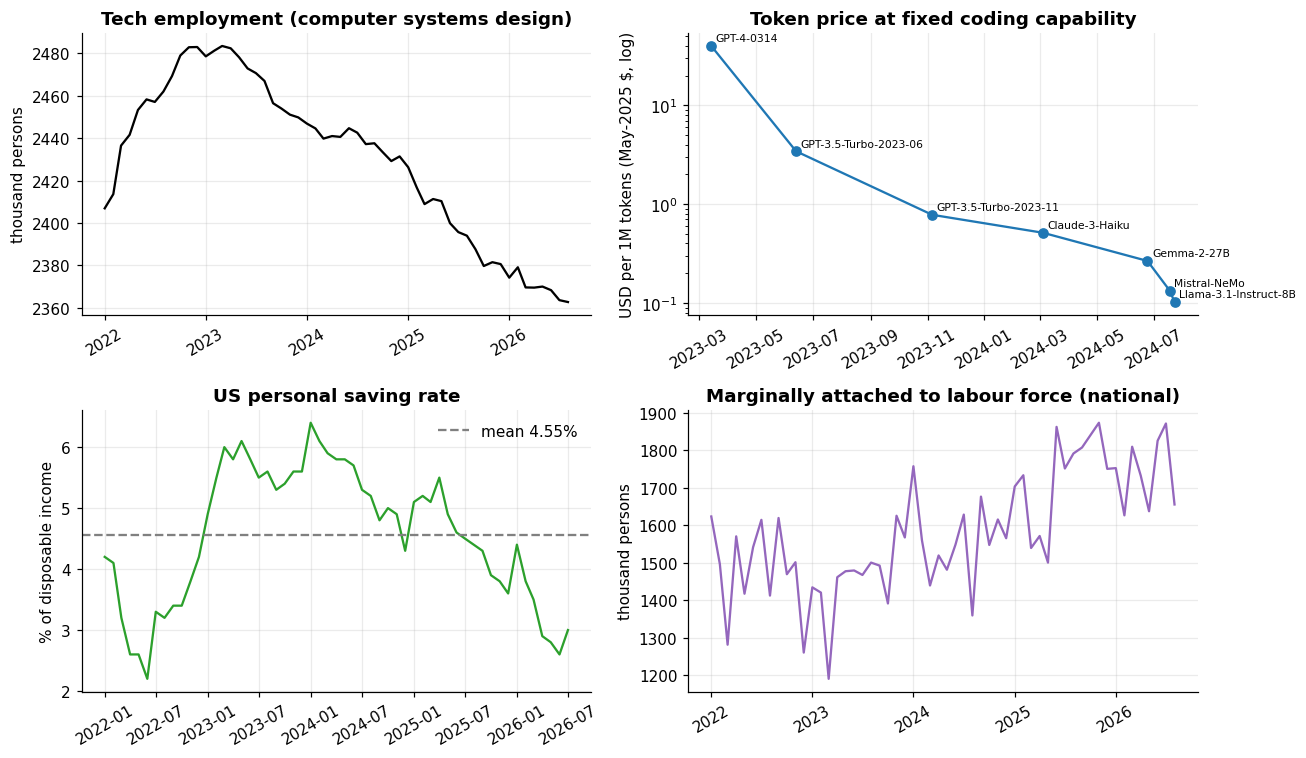

PCE.csv loaded: False


In [20]:
# CELL 2 — Data dashboard (DATA: FRED CES, CPI, PSAVERT, LNU05026642; Epoch token prices)
import sys; sys.path.insert(0, "/content")
import importlib, ai_labour_model; importlib.reload(ai_labour_model)
from ai_labour_model import *
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0, 0].plot(emp['date'], emp['value'], color='k')
ax[0, 0].set_title('Tech employment (computer systems design)'); ax[0, 0].set_ylabel('thousand persons')
ax[0, 1].semilogy(coding['date'], coding['real'], 'o-', color='#1f77b4')
for _, r in coding.iterrows():
    ax[0, 1].annotate(r['Model Name'], (r['date'], r['real']), fontsize=7, xytext=(3, 3), textcoords='offset points')
ax[0, 1].set_title('Token price at fixed coding capability'); ax[0, 1].set_ylabel('USD per 1M tokens (May-2025 $, log)')
ax[1, 0].plot(sav['date'], sav['value'], color='#2ca02c')
ax[1, 0].axhline(sav['value'].mean(), ls='--', color='grey', label=f"mean {sav['value'].mean():.2f}%")
ax[1, 0].set_title('US personal saving rate'); ax[1, 0].set_ylabel('% of disposable income'); ax[1, 0].legend()
ax[1, 1].plot(marg['date'], marg['value'], color='#9467bd')
ax[1, 1].set_title('Marginally attached to labour force (national)'); ax[1, 1].set_ylabel('thousand persons')
for a in ax.flat: a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()
print('PCE.csv loaded:', PCE_M is not None)

In [21]:
# CELL 3 — Parameter table: DATA / HAND / PLACEHOLDER. Do not report PLACEHOLDER-driven results as findings.
import sys; sys.path.insert(0, "/content")
import importlib, ai_labour_model; importlib.reload(ai_labour_model)
from ai_labour_model import *
print(pd.DataFrame([(k, P[k], v) for k, v in TAGS.items()], columns=['parameter', 'value', 'source']).to_string(index=False))
print(f"\nToken price trend (DATA): {P['pT_drift']:.2f} log points per year")
print('\nStep 6 spending categories (ALL PLACEHOLDER until BLS Consumer Expenditure Survey is loaded):')
print(CATS.to_string())

parameter         value             source
       L0  1.181350e+06 DATA x PLACEHOLDER
        W  1.234167e+04               HAND
      W_S  4.296667e+03               HAND
L_service  1.775343e+07               HAND
 pT_drift -3.637060e+00               DATA
   s_mean  4.552727e-02       DATA (floor)
     s_sd  3.000000e-02        PLACEHOLDER
   c0_rel  1.200000e+00        PLACEHOLDER
    z_rel  0.000000e+00        PLACEHOLDER
      r_b  1.000000e-01        PLACEHOLDER
      c_K  1.000000e-01        PLACEHOLDER
    eps_d  5.000000e-01        PLACEHOLDER

Token price trend (DATA): -3.64 log points per year

Step 6 spending categories (ALL PLACEHOLDER until BLS Consumer Expenditure Survey is loaded):
                        E_min     a
category                           
housing                  1800  0.30
basic food                500  0.08
fuel / transport          400  0.08
organic / premium food      0  0.07
supplements, protein        0  0.04
routine check-ups           0  0.05
other

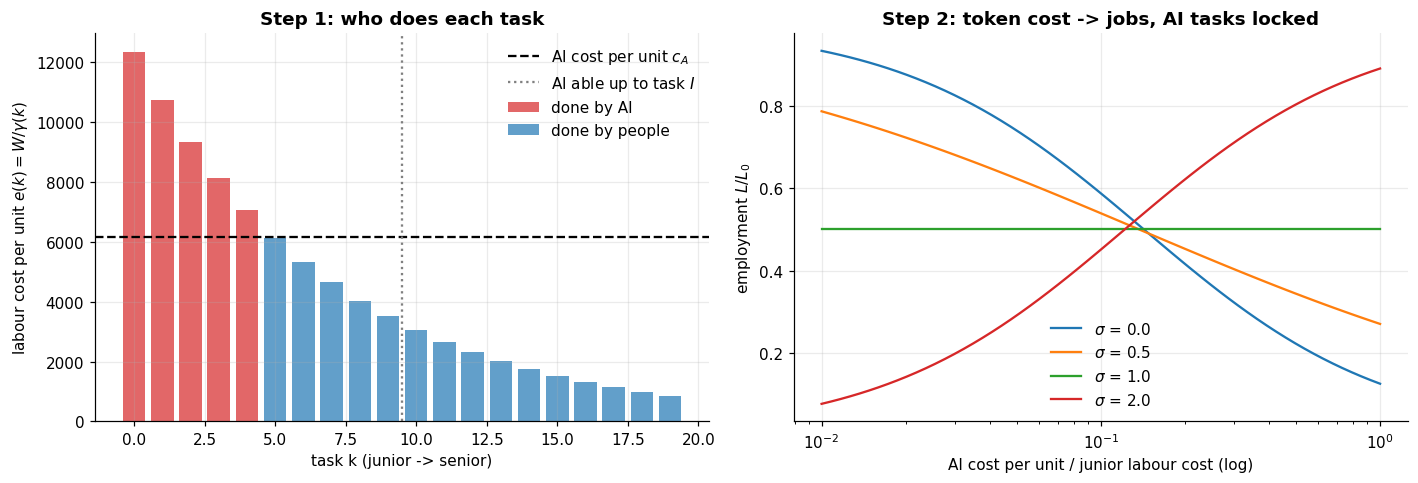

Right panel: jobs fall as AI cost rises only when sigma < 1 (flowchart arrow L2 -> L4).


In [22]:
# CELL 4 — Steps 1-2: who does each task (A&R eqs 5-6) and token cost -> jobs with AI tasks locked (fixed budget)
import sys; sys.path.insert(0, "/content")
import importlib, ai_labour_model; importlib.reload(ai_labour_model)
from ai_labour_model import *
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
c_demo = 0.5 * e[0]; A_demo = 10; k = np.arange(P['n_tasks'])
ai_demo = (k < A_demo) & (c_demo < e)
ax[0].bar(k[ai_demo], e[ai_demo], color='#d62728', alpha=0.7, label='done by AI')
ax[0].bar(k[~ai_demo], e[~ai_demo], color='#1f77b4', alpha=0.7, label='done by people')
ax[0].axhline(c_demo, color='k', ls='--', label='AI cost per unit $c_A$')
ax[0].axvline(A_demo - 0.5, color='grey', ls=':', label='AI able up to task $I$')
ax[0].set_xlabel('task k (junior -> senior)'); ax[0].set_ylabel('labour cost per unit $e(k)=W/\\gamma(k)$')
ax[0].set_title('Step 1: who does each task'); ax[0].legend()
X0 = P['W'] * P['L0']; ai_lock = (k < A_demo); c_grid = np.logspace(-2, 0, 60) * e[0]
for s in [0.0, 0.5, 1.0, 2.0]:
    ax[1].semilogx(c_grid / e[0], [headcount(ai_lock, c, X0, s) / P['L0'] for c in c_grid], label=f'$\\sigma$ = {s}')
ax[1].set_xlabel('AI cost per unit / junior labour cost (log)'); ax[1].set_ylabel('employment $L/L_0$')
ax[1].set_title('Step 2: token cost -> jobs, AI tasks locked'); ax[1].legend()
plt.tight_layout(); plt.show()
print('Right panel: jobs fall as AI cost rises only when sigma < 1 (flowchart arrow L2 -> L4).')

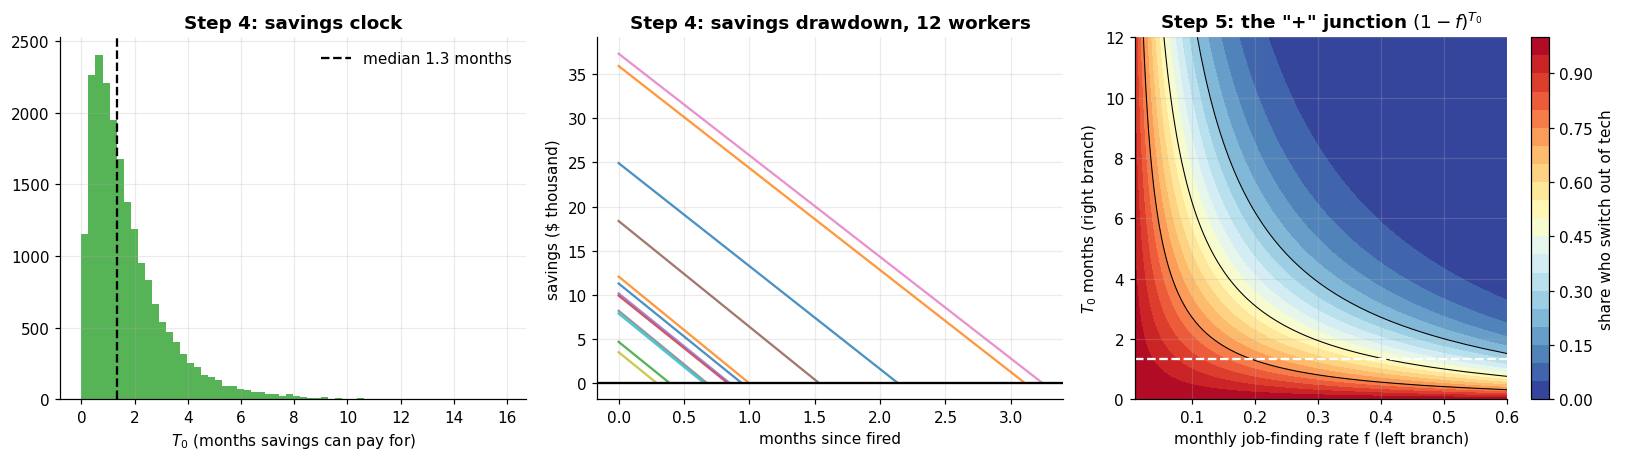

In [23]:
# CELL 5 — Steps 3-5: savings clock T0 (Applegate & Janssen Sect. 2 p.5 + our drawdown) and the "+" junction (1-f)^T0
import sys; sys.path.insert(0, "/content")
import importlib, ai_labour_model; importlib.reload(ai_labour_model)
from ai_labour_model import *
rng = np.random.default_rng(RNG_SEED)
a_, b_ = beta_ab(P['s_mean'], P['s_sd'])
s_draw = rng.beta(a_, b_, 20000); ns_draw = rng.integers(P['ns_min'], P['ns_max'] + 1, 20000)
z = P['z_rel'] * P['W']
T0_draw = (s_draw * P['W'] * ns_draw - P['m_min_rel'] * P['W']) / ((1 - s_draw) * P['W'] - z)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
ax[0].hist(T0_draw, bins=60, color='#2ca02c', alpha=0.8)
ax[0].axvline(np.median(T0_draw), color='k', ls='--', label=f'median {np.median(T0_draw):.1f} months')
ax[0].set_xlabel('$T_0$ (months savings can pay for)'); ax[0].set_title('Step 4: savings clock'); ax[0].legend()
for i in range(12):
    m0 = s_draw[i] * P['W'] * ns_draw[i]; tt = np.linspace(0, max(T0_draw[i], 0.1), 30)
    ax[1].plot(tt, (m0 - ((1 - s_draw[i]) * P['W'] - z) * tt) / 1000, alpha=0.8)
ax[1].axhline(0, color='k'); ax[1].set_xlabel('months since fired'); ax[1].set_ylabel('savings ($ thousand)')
ax[1].set_title('Step 4: savings drawdown, 12 workers')
FF, TT = np.meshgrid(np.linspace(0.01, 0.6, 80), np.linspace(0, 12, 80))
im = ax[2].contourf(FF, TT, (1 - FF) ** TT, levels=20, cmap='RdYlBu_r')
ax[2].contour(FF, TT, (1 - FF) ** TT, levels=[0.25, 0.5, 0.75], colors='k', linewidths=0.7)
ax[2].axhline(np.median(T0_draw), color='w', ls='--')
plt.colorbar(im, ax=ax[2], label='share who switch out of tech')
ax[2].set_xlabel('monthly job-finding rate f (left branch)'); ax[2].set_ylabel('$T_0$ months (right branch)')
ax[2].set_title('Step 5: the "+" junction $(1-f)^{T_0}$')
plt.tight_layout(); plt.show()

In [25]:
# CELL 6 — Run the base Monte Carlo (3 sigma x 3 token-cost scenarios x 30 runs, 2023-2030) and save to disk
import sys; sys.path.insert(0, "/content")
import importlib, ai_labour_model; importlib.reload(ai_labour_model)
from ai_labour_model import *
RES, END, PATHS, MONTHS = get_results(force=True)
print('Saved to', os.path.join(RES_DIR, 'base.pkl'))

  done: sigma=0.0, data: q fixed
  done: sigma=0.0, q offsets price
  done: sigma=0.0, q outruns price
  done: sigma=0.5, data: q fixed
  done: sigma=0.5, q offsets price
  done: sigma=0.5, q outruns price
  done: sigma=1.0, data: q fixed
  done: sigma=1.0, q offsets price
  done: sigma=1.0, q outruns price
Saved to /content/results/base.pkl


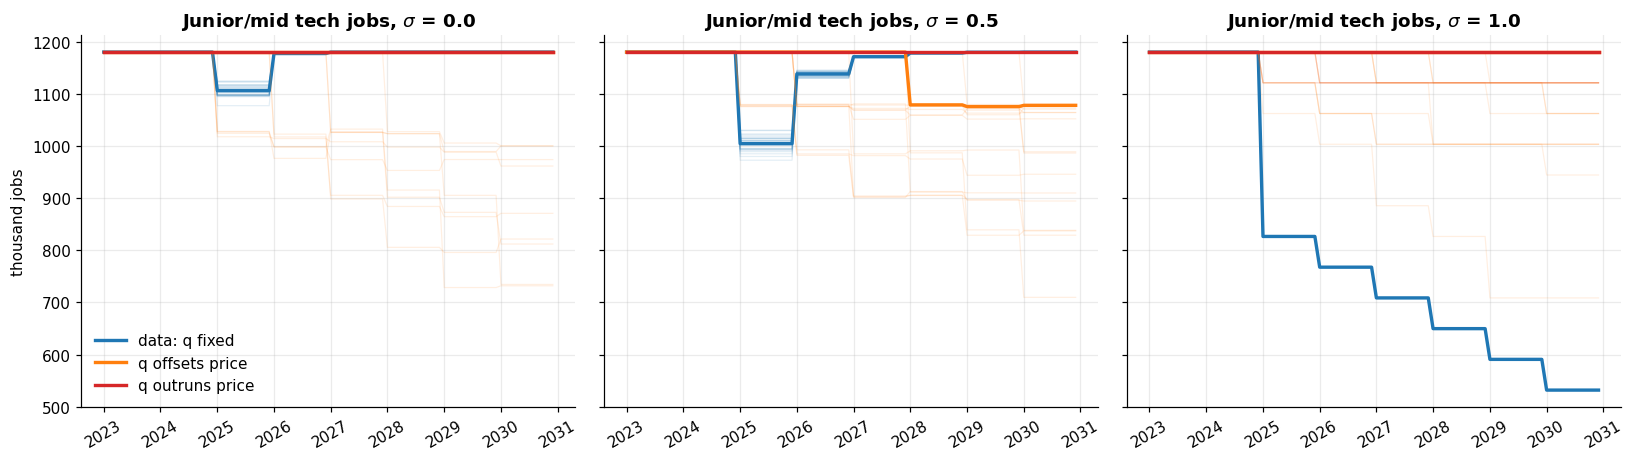

In [26]:
# CELL 7 — Applegate & Janssen Fig 2 style: junior/mid tech jobs, 30 runs per scenario
import sys; sys.path.insert(0, "/content")
import importlib, ai_labour_model; importlib.reload(ai_labour_model)
from ai_labour_model import *
RES, END, PATHS, MONTHS = get_results()
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
for a, s in zip(ax, P['sigmas']):
    for cname, col in C_COLORS.items():
        arr = RES[(s, cname)]['jobs'] / 1000
        for row in arr: a.plot(MONTHS, row, color=col, alpha=0.12, lw=0.8)
        a.plot(MONTHS, np.median(arr, 0), color=col, lw=2.2, label=cname)
    a.set_title(f'Junior/mid tech jobs, $\\sigma$ = {s}'); a.tick_params(axis='x', rotation=30)
ax[0].set_ylabel('thousand jobs'); ax[0].legend()
plt.tight_layout(); plt.show()

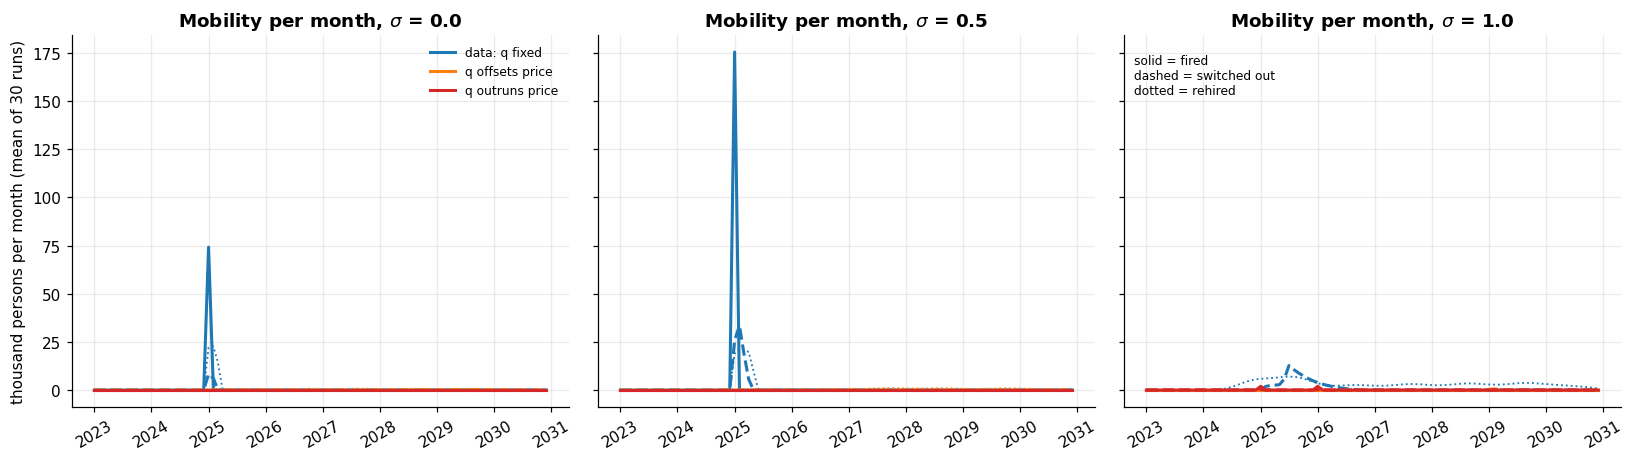

In [27]:
# CELL 8 — Applegate & Janssen Fig 3 style: fired (solid), switched out (dashed), rehired (dotted), smoothed
import sys; sys.path.insert(0, "/content")
import importlib, ai_labour_model; importlib.reload(ai_labour_model)
from ai_labour_model import *
RES, END, PATHS, MONTHS = get_results()
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
for a, s in zip(ax, P['sigmas']):
    for cname, col in C_COLORS.items():
        R_ = RES[(s, cname)]
        a.plot(MONTHS, smooth(R_['fired'].mean(0)) / 1000, color=col, lw=2, label=cname)
        a.plot(MONTHS, smooth(R_['switched'].mean(0)) / 1000, color=col, lw=2, ls='--')
        a.plot(MONTHS, smooth(R_['rehired'].mean(0)) / 1000, color=col, lw=1.2, ls=':')
    a.set_title(f'Mobility per month, $\\sigma$ = {s}'); a.tick_params(axis='x', rotation=30)
ax[0].set_ylabel('thousand persons per month (mean of 30 runs)'); ax[0].legend(fontsize=8)
ax[2].text(0.02, 0.95, 'solid = fired\ndashed = switched out\ndotted = rehired', transform=ax[2].transAxes, va='top', fontsize=8)
plt.tight_layout(); plt.show()

In [28]:
# CELL 9 — Applegate & Janssen Table 2 style: final-month mean (sd) and Welch two-sample t-tests
import sys; sys.path.insert(0, "/content")
import importlib, ai_labour_model; importlib.reload(ai_labour_model)
from ai_labour_model import *
RES, END, PATHS, MONTHS = get_results()
rows = []
for (s, cname), R_ in RES.items():
    rows.append(dict(sigma=s, scenario=cname,
                     jobs_k=f"{R_['jobs'][:, -1].mean()/1e3:.1f} ({R_['jobs'][:, -1].std()/1e3:.1f})",
                     switched_k=f"{R_['S'][:, -1].mean()/1e3:.1f} ({R_['S'][:, -1].std()/1e3:.1f})",
                     total_fired_k=f"{R_['fired'].sum(1).mean()/1e3:.1f} ({R_['fired'].sum(1).std()/1e3:.1f})",
                     dC_bn_month=f"{R_['dC'][:, -1].mean()/1e9:.2f} ({R_['dC'][:, -1].std()/1e9:.2f})"))
print(pd.DataFrame(rows).to_string(index=False))
names = list(P['q_scen'])
print('\nWelch t-test, final switched count, between token-cost scenarios (same sigma):')
for s in P['sigmas']:
    for i in range(3):
        for j in range(i + 1, 3):
            t, p = stats.ttest_ind(RES[(s, names[i])]['S'][:, -1], RES[(s, names[j])]['S'][:, -1], equal_var=False)
            print(f'  sigma={s}: {names[i]} vs {names[j]}: t={t:.2f}, p={p:.3g}')

 sigma        scenario         jobs_k   switched_k total_fired_k  dC_bn_month
   0.0   data: q fixed   1181.3 (0.0)   14.6 (5.7)   74.2 (10.2) -0.12 (0.05)
   0.0 q offsets price 1090.7 (149.6)  30.1 (52.6)  95.8 (159.4) -0.12 (0.23)
   0.0 q outruns price   1181.3 (0.0)    0.0 (0.0)     0.0 (0.0)  0.00 (0.00)
   0.5   data: q fixed   1181.3 (0.0)  84.2 (11.6)  175.5 (13.5) -0.66 (0.09)
   0.5 q offsets price 1058.9 (132.4)  33.0 (43.7) 125.8 (134.0) -0.11 (0.20)
   0.5 q outruns price   1181.3 (0.0)    0.0 (0.0)     0.0 (0.0)  0.00 (0.00)
   1.0   data: q fixed    531.6 (0.0) 301.6 (10.0)   649.7 (0.0) -1.55 (0.08)
   1.0 q offsets price 1116.4 (101.6)  10.4 (25.8)  65.0 (101.6) -0.00 (0.10)
   1.0 q outruns price  1177.4 (14.7)    0.6 (2.1)    3.9 (14.7)  0.00 (0.00)

Welch t-test, final switched count, between token-cost scenarios (same sigma):
  sigma=0.0: data: q fixed vs q offsets price: t=-1.58, p=0.125
  sigma=0.0: data: q fixed vs q outruns price: t=13.67, p=3.62e-14
  sigma=0

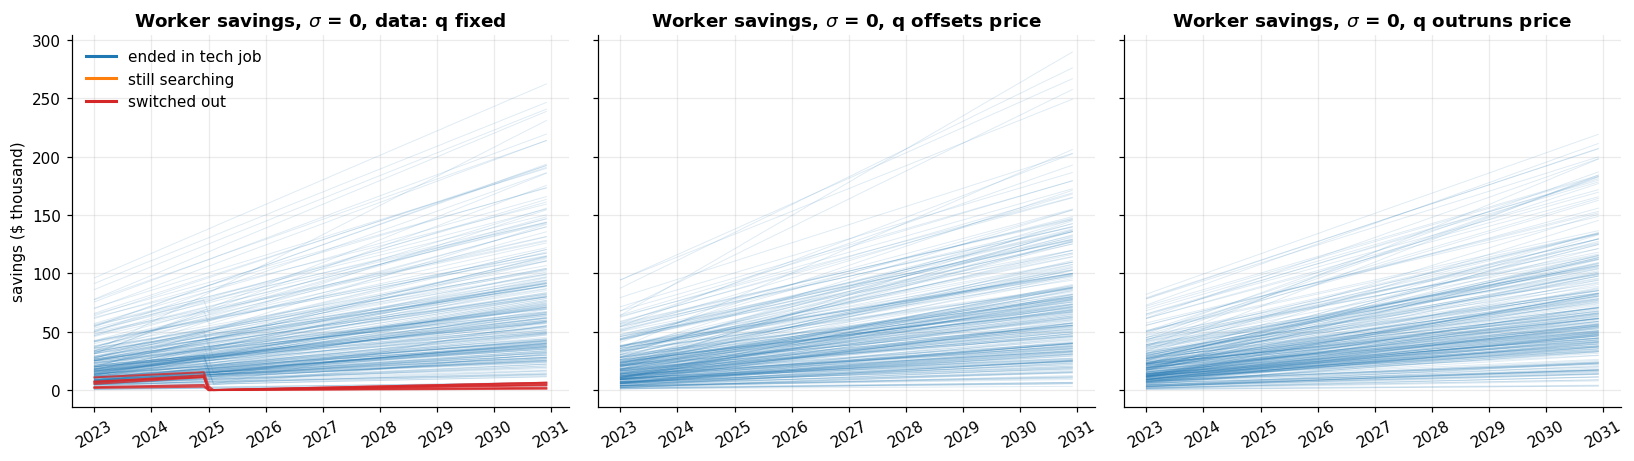

In [29]:
# CELL 10 — Applegate & Janssen Fig 5 style: each worker's savings over time (one run, 300 workers)
import sys; sys.path.insert(0, "/content")
import importlib, ai_labour_model; importlib.reload(ai_labour_model)
from ai_labour_model import *
RES, END, PATHS, MONTHS = get_results()
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
for a, cname in zip(ax, P['q_scen']):
    paths, st = PATHS[(0.0, cname)]
    for code, col, al, lw in [(0, '#1f77b4', 0.15, 0.6), (1, '#ff7f0e', 0.6, 1.0), (2, '#d62728', 0.8, 1.3)]:
        for i in np.where(st == code)[0]:
            a.plot(MONTHS, paths[:, i] / 1000, color=col, alpha=al, lw=lw)
        a.plot([], [], color=col, lw=2, label={0: 'ended in tech job', 1: 'still searching', 2: 'switched out'}[code])
    a.set_title(f'Worker savings, $\\sigma$ = 0, {cname}'); a.tick_params(axis='x', rotation=30)
ax[0].set_ylabel('savings ($ thousand)'); ax[0].legend()
plt.tight_layout(); plt.show()

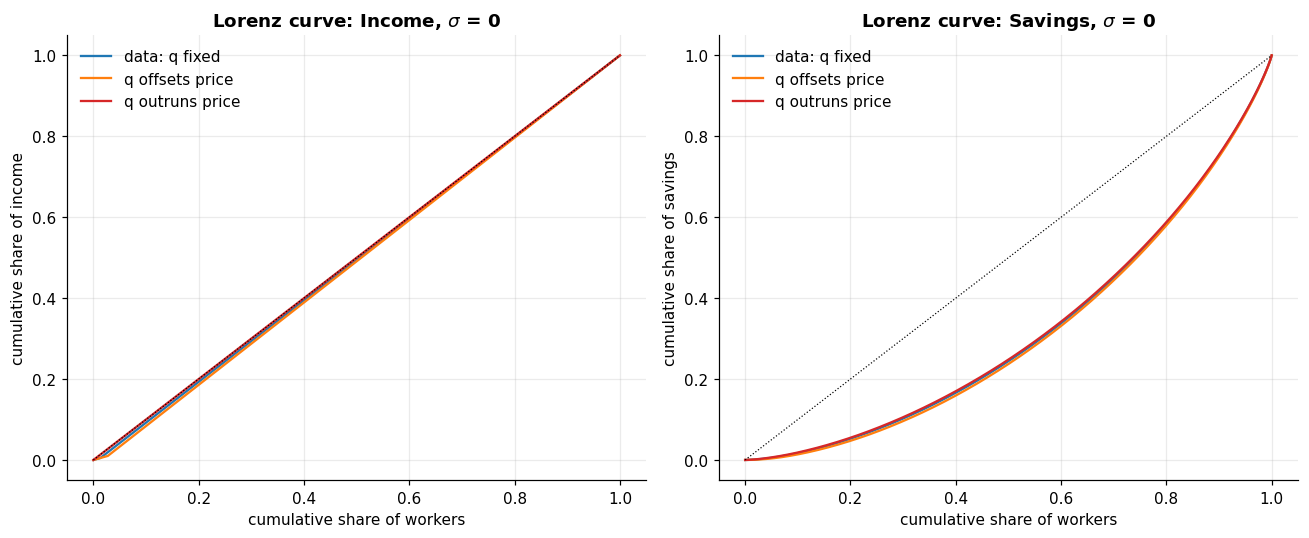

 sigma        scenario  income_Gini  wealth_Gini
   0.0   data: q fixed          0.8         36.4
   0.0 q offsets price          1.7         37.4
   0.0 q outruns price          0.0         35.9
   0.5   data: q fixed          4.9         39.3
   0.5 q offsets price          2.0         37.6
   0.5 q outruns price          0.0         36.1
   1.0   data: q fixed         19.7         52.2
   1.0 q offsets price          0.6         36.6
   1.0 q outruns price          0.0         35.8
Caution: income is nearly equal by construction (one tech wage, one service wage); savings inequality
comes mainly from the PLACEHOLDERS s_sd and n_s.


In [30]:
# CELL 11 — Applegate & Janssen Fig 8 / Table 5 style: Lorenz curves and Gini (income, savings)
import sys; sys.path.insert(0, "/content")
import importlib, ai_labour_model; importlib.reload(ai_labour_model)
from ai_labour_model import *
RES, END, PATHS, MONTHS = get_results()
fig, ax = plt.subplots(1, 2, figsize=(12, 5)); rows = []
for (s, cname), ends in END.items():
    inc = np.concatenate([en['income'] for en in ends]); wl = np.concatenate([en['wealth'] for en in ends])
    rows.append(dict(sigma=s, scenario=cname, income_Gini=round(100 * gini(inc), 1), wealth_Gini=round(100 * gini(wl), 1)))
    if s == 0.0:
        ax[0].plot(*lorenz(inc), color=C_COLORS[cname], label=cname); ax[1].plot(*lorenz(wl), color=C_COLORS[cname], label=cname)
for a, ttl in zip(ax, ['Income', 'Savings']):
    a.plot([0, 1], [0, 1], 'k:', lw=0.8); a.set_title(f'Lorenz curve: {ttl}, $\\sigma$ = 0')
    a.set_xlabel('cumulative share of workers'); a.set_ylabel(f'cumulative share of {ttl.lower()}'); a.legend()
plt.tight_layout(); plt.show()
print(pd.DataFrame(rows).to_string(index=False))
print('Caution: income is nearly equal by construction (one tech wage, one service wage); savings inequality')
print('comes mainly from the PLACEHOLDERS s_sd and n_s.')

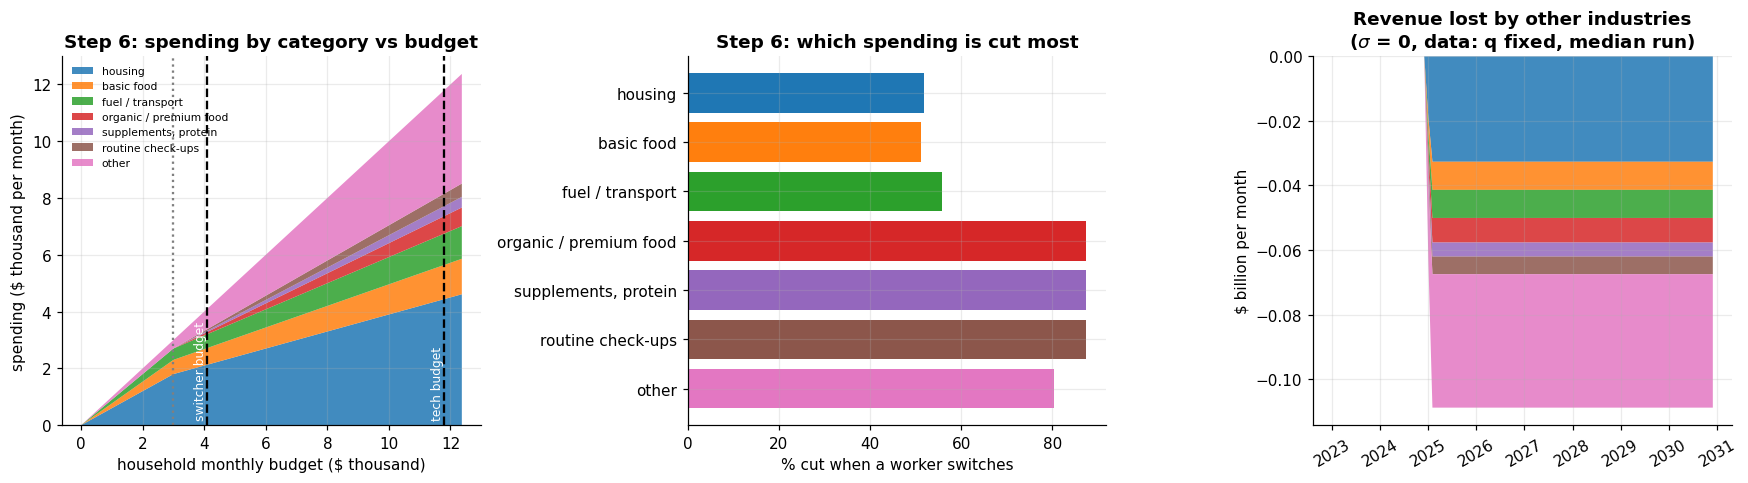

                        tech budget $  switcher budget $  cut %
category                                                       
housing                        4434.0             2130.0   52.0
basic food                     1202.0              588.0   51.1
fuel / transport               1102.0              488.0   55.7
organic / premium food          615.0               77.0   87.5
supplements, protein            351.0               44.0   87.5
routine check-ups               439.0               55.0   87.5
other                          3636.0              718.0   80.2


In [31]:
# CELL 13 — Step 6: where the lost spending falls (Stone-Geary; Geary 1950, Stone 1954). CATS values are PLACEHOLDER.
import sys; sys.path.insert(0, "/content")
import importlib, ai_labour_model; importlib.reload(ai_labour_model)
from ai_labour_model import *
RES, END, PATHS, MONTHS = get_results()
B_tech = (1 - P['s_mean']) * P['W']
B_sw = (1 - P['s_mean']) * P['W_S']
budgets = np.linspace(0, B_tech * 1.05, 300)
E_curve = np.array([les(B) for B in budgets])
cols = plt.cm.tab10(np.arange(len(CATS)))
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].stackplot(budgets / 1000, (E_curve / 1000).T, labels=CATS.index, colors=cols, alpha=0.85)
for B, lab in [(B_sw, 'switcher budget'), (B_tech, 'tech budget')]:
    ax[0].axvline(B / 1000, color='k', ls='--'); ax[0].text(B / 1000, 0.2, lab, rotation=90, va='bottom', ha='right', fontsize=8, color='w')
ax[0].axvline(CATS['E_min'].sum() / 1000, color='grey', ls=':')
ax[0].set_xlabel('household monthly budget ($ thousand)'); ax[0].set_ylabel('spending ($ thousand per month)')
ax[0].set_title('Step 6: spending by category vs budget'); ax[0].legend(fontsize=7, loc='upper left', bbox_to_anchor=(0, 1))
cut = les(B_tech) - les(B_sw); pct = 100 * cut / les(B_tech)
ax[1].barh(CATS.index, pct, color=cols); ax[1].invert_yaxis()
ax[1].set_xlabel('% cut when a worker switches'); ax[1].set_title('Step 6: which spending is cut most')
S_med = np.median(RES[(0.0, 'data: q fixed')]['S'], 0)
loss_k = -np.outer(S_med, cut) / 1e9                  # $ billion per month, by category
ax[2].stackplot(MONTHS, loss_k.T, labels=CATS.index, colors=cols, alpha=0.85)
ax[2].set_ylabel('$ billion per month'); ax[2].set_title('Revenue lost by other industries\n($\\sigma$ = 0, data: q fixed, median run)')
ax[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()
print(pd.DataFrame({'tech budget $': les(B_tech).round(0), 'switcher budget $': les(B_sw).round(0),
                    'cut %': pct.round(1)}, index=CATS.index).to_string())

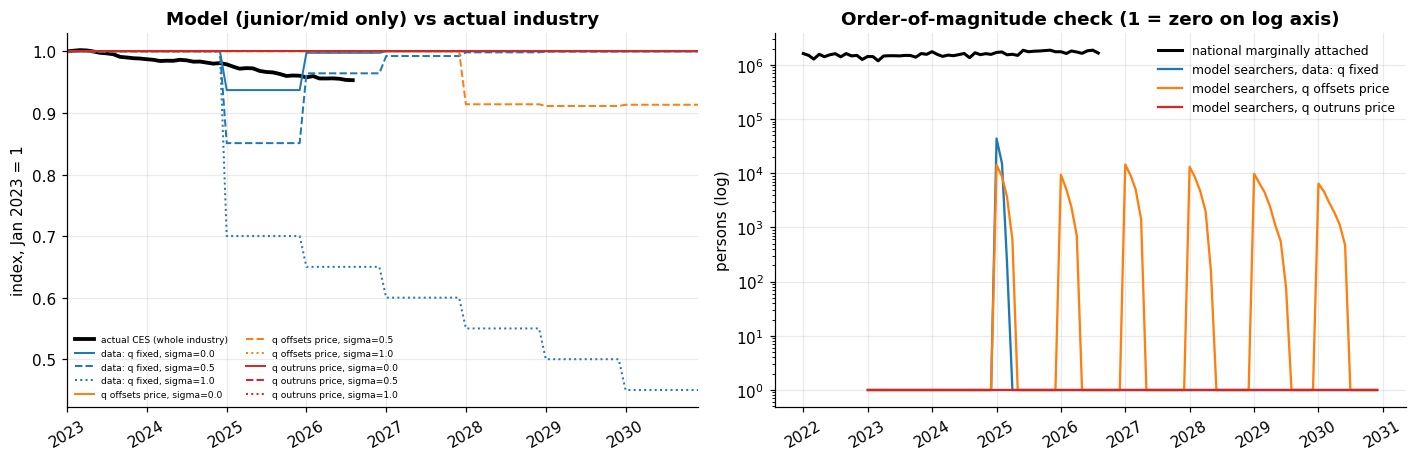

Plausibility check only: the model covers junior/mid workers and depends on PLACEHOLDERS.


In [32]:
# CELL 14 — Check against data: model jobs vs actual CES path; model searchers vs national marginally attached
import sys; sys.path.insert(0, "/content")
import importlib, ai_labour_model; importlib.reload(ai_labour_model)
from ai_labour_model import *
RES, END, PATHS, MONTHS = get_results()
ces = emp.set_index('date')['value']; ces_idx = ces / ces.loc['2023-01-01']
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
ax[0].plot(ces_idx.index, ces_idx.values, 'k', lw=2.5, label='actual CES (whole industry)')
for cname, col in C_COLORS.items():
    for s, ls in zip(P['sigmas'], ['-', '--', ':']):
        ax[0].plot(MONTHS, np.median(RES[(s, cname)]['jobs'], 0) / P['L0'], color=col, ls=ls, lw=1.3, label=f'{cname}, sigma={s}')
ax[0].set_xlim(pd.Timestamp('2023-01-01'), MONTHS[-1]); ax[0].set_ylabel('index, Jan 2023 = 1')
ax[0].set_title('Model (junior/mid only) vs actual industry'); ax[0].legend(fontsize=6, ncol=2)
ax[1].semilogy(marg['date'], marg['value'] * 1000, 'k', lw=2, label='national marginally attached')
for cname, col in C_COLORS.items():
    ax[1].semilogy(MONTHS, np.maximum(RES[(0.0, cname)]['U'].mean(0), 1), color=col, label=f'model searchers, {cname}')
ax[1].set_title('Order-of-magnitude check (1 = zero on log axis)'); ax[1].set_ylabel('persons (log)'); ax[1].legend(fontsize=8)
for a in ax: a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()
print('Plausibility check only: the model covers junior/mid workers and depends on PLACEHOLDERS.')

Running long-run set "tasks" (6 scenarios x 20 runs)...
  done: data: q fixed | nu=0.0
  done: data: q fixed | nu=0.02
  done: data: q fixed | nu=0.05
  done: q offsets price | nu=0.0
  done: q offsets price | nu=0.02
  done: q offsets price | nu=0.05


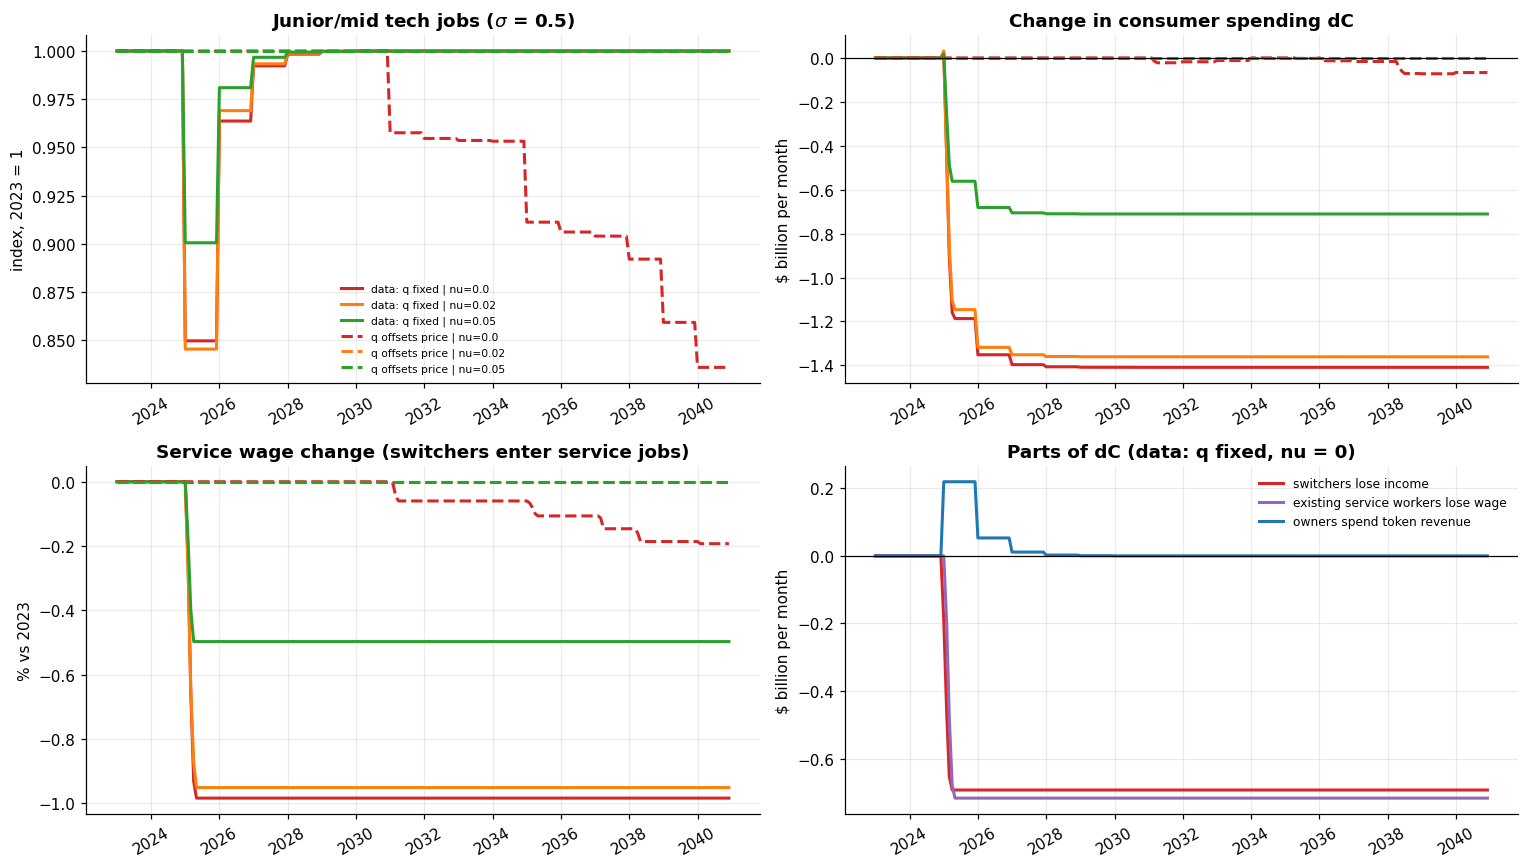

In [33]:
# CELL 15 — Step 7 long run to 2040: new tasks (A&R: N rises) and service wages falling as switchers enter
import sys; sys.path.insert(0, "/content")
import importlib, ai_labour_model; importlib.reload(ai_labour_model)
from ai_labour_model import *
# nu = new tech tasks per year as a share of all tasks. Her assumption: most tech workers do not create
# new tasks -> low nu. nu is PLACEHOLDER; the sweep shows how much it matters.
SET = {}
for cname in ['data: q fixed', 'q offsets price']:
    for nu in [0.0, 0.02, 0.05]:
        SET[f'{cname} | nu={nu}'] = dict(sigma=0.5, cname=cname, nu=nu, e_X=0.0, wage_resp=True)
LR, M18 = get_longrun('tasks', SET)
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
nu_col = {0.0: '#d62728', 0.02: '#ff7f0e', 0.05: '#2ca02c'}
for lab, R_ in LR.items():
    cname, nu = lab.split(' | nu=')[0], float(lab.split('=')[1])
    ls = '-' if cname == 'data: q fixed' else '--'
    ax[0, 0].plot(M18, np.median(R_['jobs'], 0) / P['L0'], color=nu_col[nu], ls=ls, lw=2, label=lab)
    ax[0, 1].plot(M18, np.median(R_['dC'], 0) / 1e9, color=nu_col[nu], ls=ls, lw=2)
    ax[1, 0].plot(M18, 100 * (np.median(R_['W_S'], 0) / P['W_S'] - 1), color=nu_col[nu], ls=ls, lw=2)
ax[0, 0].set_title('Junior/mid tech jobs ($\\sigma$ = 0.5)'); ax[0, 0].set_ylabel('index, 2023 = 1'); ax[0, 0].legend(fontsize=7)
ax[0, 1].axhline(0, color='k', lw=0.8); ax[0, 1].set_title('Change in consumer spending dC'); ax[0, 1].set_ylabel('$ billion per month')
ax[1, 0].set_title('Service wage change (switchers enter service jobs)'); ax[1, 0].set_ylabel('% vs 2023')
R0 = LR['data: q fixed | nu=0.0']
parts = {'switchers lose income': R0['dC_switch'], 'existing service workers lose wage': R0['dC_service'],
         'owners spend token revenue': R0['dC_owner']}
for (nm, arr), col in zip(parts.items(), ['#d62728', '#9467bd', '#1f77b4']):
    ax[1, 1].plot(M18, np.median(arr, 0) / 1e9, color=col, lw=2, label=nm)
ax[1, 1].axhline(0, color='k', lw=0.8); ax[1, 1].set_title('Parts of dC (data: q fixed, nu = 0)')
ax[1, 1].set_ylabel('$ billion per month'); ax[1, 1].legend(fontsize=8)
for a in ax.flat: a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

In [35]:
# CELL 16 — Step 7: does a downward spiral start? Budget feedback X(y+1) = X(y)(1 + e_X dAD/AD). Needs PCE.csv.
import sys; sys.path.insert(0, "/content")
import importlib, ai_labour_model; importlib.reload(ai_labour_model)
from ai_labour_model import *
if PCE_M is None:
    print('PCE.csv not found in', DATA_DIR, '- download FRED series PCE as CSV, upload it with Cell 0, then rerun Cell 1 and this cell.')
else:
    SET = {f'e_X={ex}': dict(sigma=0.5, cname='data: q fixed', nu=0.0, e_X=ex, wage_resp=True)
           for ex in [0.0, 10.0, 100.0, 1000.0]}
    LR, M18 = get_longrun('feedback', SET)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
    for (lab, R_), col in zip(LR.items(), ['k', '#1f77b4', '#ff7f0e', '#d62728']):
        ax[0].plot(M18, np.median(R_['jobs'], 0) / P['L0'], color=col, lw=2, label=lab)
        ax[1].plot(M18, np.median(R_['X'], 0) / (P['W'] * P['L0']), color=col, lw=2, label=lab)
    ax[0].set_title('Junior/mid tech jobs with budget feedback'); ax[0].set_ylabel('index, 2023 = 1'); ax[0].legend()
    ax[1].set_title('Tech budget X'); ax[1].set_ylabel('index, 2023 = 1')
    for a in ax: a.tick_params(axis='x', rotation=30)
    plt.tight_layout(); plt.show()
    last = LR['e_X=0.0']['dAD'][:, -12:].mean() / PCE_M
    print(f'Demand loss relative to national monthly PCE, final year (e_X = 0): {100*last:.4f}%')
    print('e_X is PLACEHOLDER: the sweep shows how strong the feedback must be before a spiral appears.')

PCE.csv not found in /content/data - download FRED series PCE as CSV, upload it with Cell 0, then rerun Cell 1 and this cell.
